In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf


In [2]:
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14,6)

# Load the preprocessed dataset

In [3]:
data=pd.read_csv('../datasets/PJME_preprocessd.csv',parse_dates=['Datetime'],index_col='Datetime')

In [4]:
data.head()

,PJME_MW,PJME_MW_Scaled,Hour,Day,Week,Month,DayOfWeek,Weekend,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingStd_24,RollingMean_168
Datetime,,,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,0.433011,1,8,2,1,1,0,31187.0,26862.0,27100.0,30393.0,33560.208333,4425.965952,32513.869048
2002-01-08 02:00:00,28670.0,0.409021,2,8,2,1,1,0,29445.0,25976.0,26097.0,29265.0,33672.458333,4256.159403,32510.327381
2002-01-08 03:00:00,28375.0,0.399889,3,8,2,1,1,0,28670.0,25641.0,25793.0,28357.0,33786.375000,4064.104959,32510.434524
2002-01-08 04:00:00,28542.0,0.405058,4,8,2,1,1,0,28375.0,25666.0,25657.0,27899.0,33906.208333,3851.076461,32514.261905
2002-01-08 05:00:00,29261.0,0.427316,5,8,2,1,1,0,28542.0,26328.0,25778.0,28057.0,34028.416667,3640.941409,32521.428571


# Hourly demand patterns

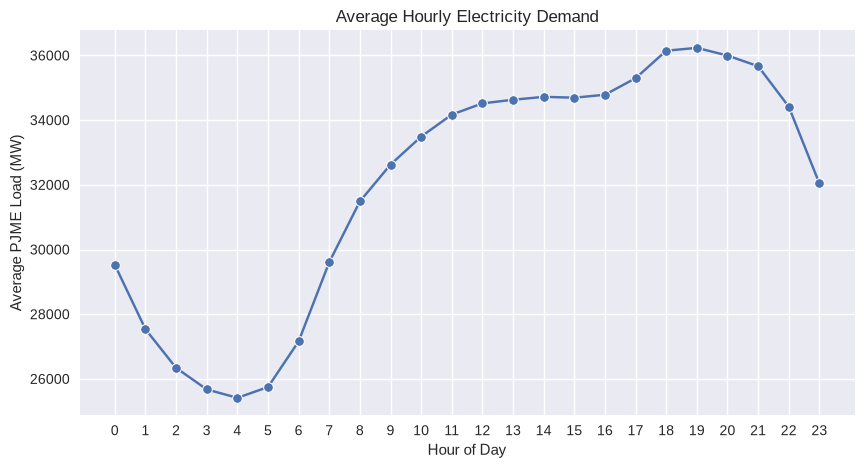

In [5]:
hourly_profile = data.groupby('Hour')['PJME_MW'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_profile.index, y=hourly_profile.values, marker='o')
plt.title('Average Hourly Electricity Demand')
plt.xlabel('Hour of Day')
plt.ylabel('Average PJME Load (MW)')
plt.xticks(range(24))
plt.show()

# Daily demand patterns

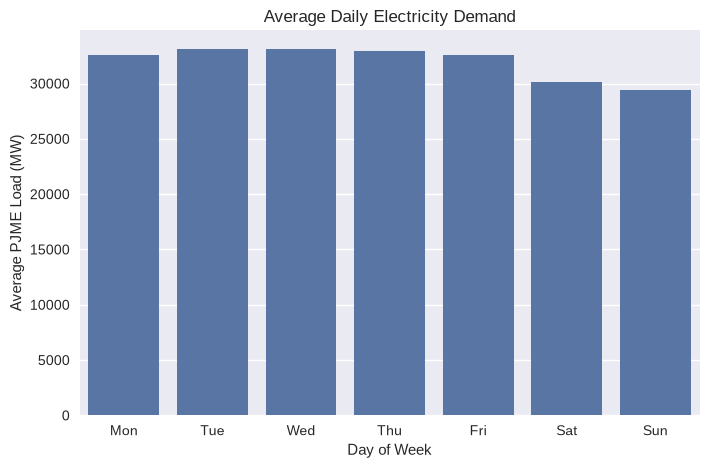

In [6]:
daily_profile = data.groupby('DayOfWeek')['PJME_MW'].mean()
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
plt.figure(figsize=(8,5))
sns.barplot(x=day_names, y=daily_profile.values)
plt.title('Average Daily Electricity Demand')
plt.xlabel('Day of Week')
plt.ylabel('Average PJME Load (MW)')
plt.show()

# Weekly seasonality

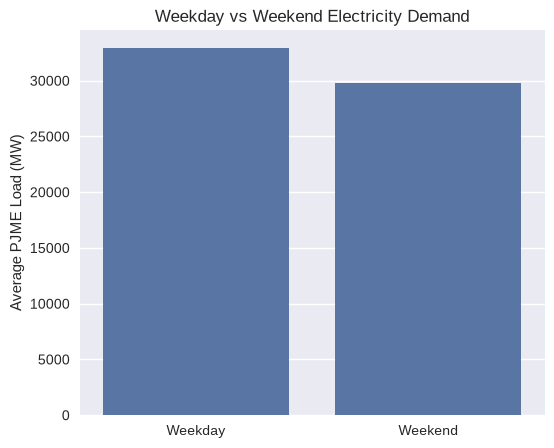

In [7]:
weekend_profile = data.groupby('Weekend')['PJME_MW'].mean()

labels = ['Weekday', 'Weekend']

plt.figure(figsize=(6,5))
sns.barplot(x=labels, y=weekend_profile.values)
plt.title('Weekday vs Weekend Electricity Demand')
plt.ylabel('Average PJME Load (MW)')
plt.show()

# Monthly and annual seasonality

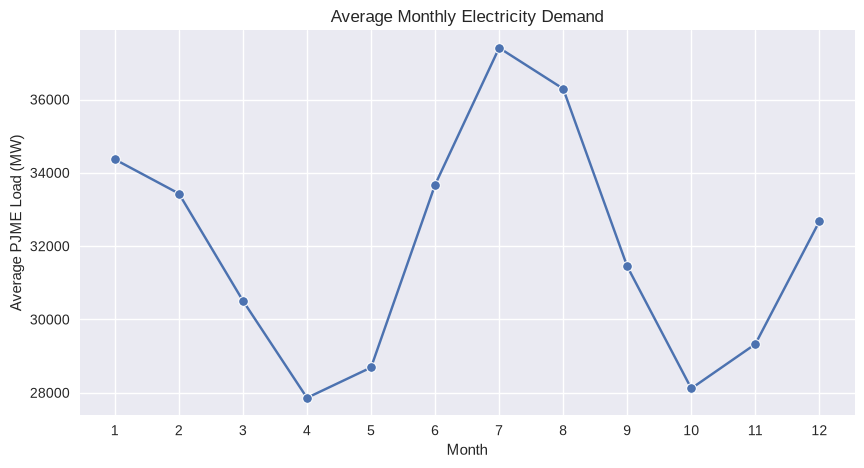

In [8]:
monthly_profile = data.groupby('Month')['PJME_MW'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_profile.index, y=monthly_profile.values, marker='o')
plt.title('Average Monthly Electricity Demand')
plt.xlabel('Month')
plt.ylabel('Average PJME Load (MW)')
plt.xticks(range(1,13))
plt.show()

# Peak vs off-peak demand

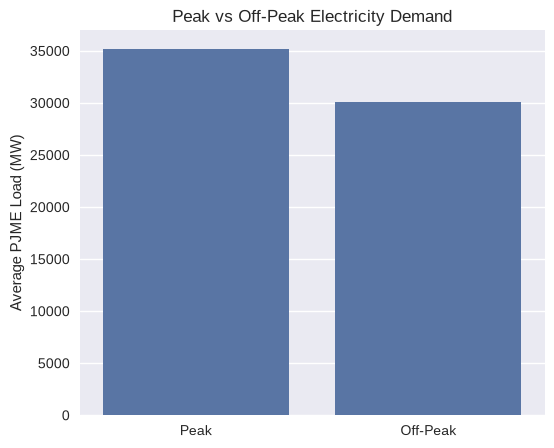

In [11]:
peak = data[data['Hour'].between(12,20)]
off_peak = data[~data['Hour'].between(12,20)]

peak_values = [peak['PJME_MW'].mean(), off_peak['PJME_MW'].mean()]

plt.figure(figsize=(6,5))
sns.barplot(x=['Peak', 'Off-Peak'], y=peak_values)
plt.title('Peak vs Off-Peak Electricity Demand')
plt.ylabel('Average PJME Load (MW)')
plt.show()

# Heatmap of hour vs day

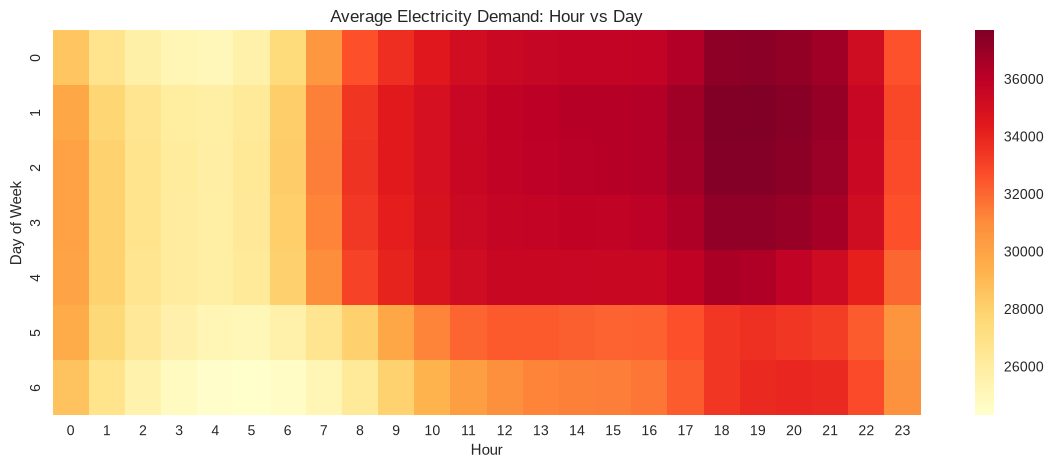

In [16]:
heatmap_data = data.pivot_table(
    values='PJME_MW',
    index='DayOfWeek',
    columns='Hour',
    aggfunc='mean'
)

plt.figure(figsize=(14,5))
sns.heatmap(heatmap_data, cmap='YlOrRd')
plt.title('Average Electricity Demand: Hour vs Day')
plt.xlabel('Hour')
plt.ylabel('Day of Week')
plt.show()

# Rolling mean and rolling standard deviation

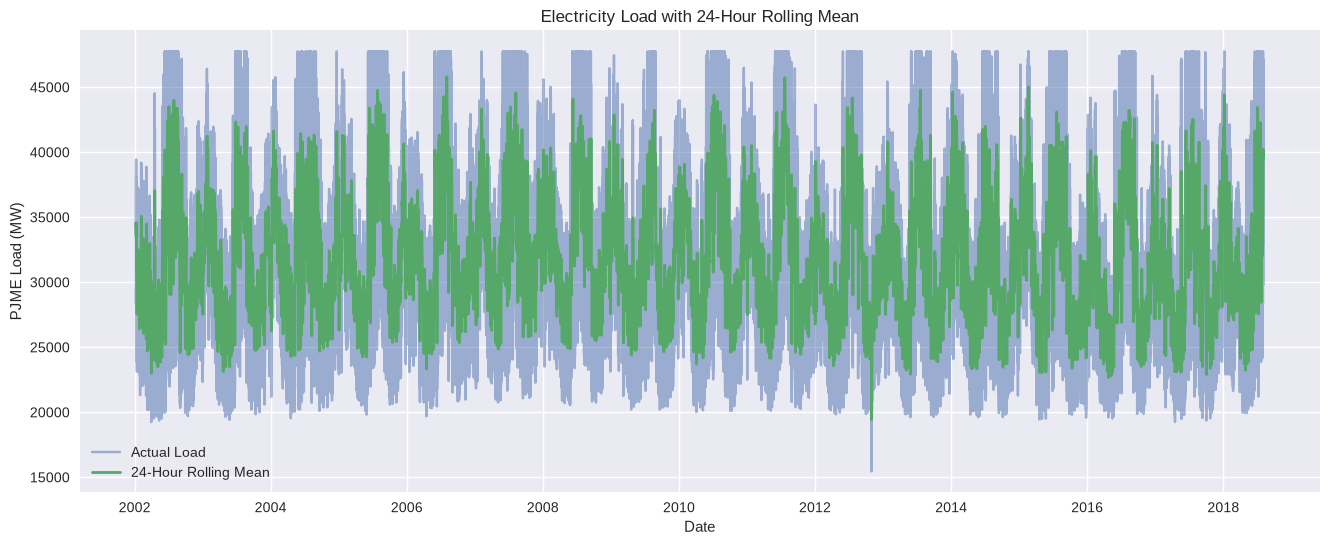

In [13]:
plt.figure(figsize=(16,6))

plt.plot(data['PJME_MW'], label='Actual Load', alpha=0.5)
plt.plot(data['RollingMean_24'], label='24-Hour Rolling Mean', linewidth=2)

plt.title('Electricity Load with 24-Hour Rolling Mean')
plt.xlabel('Date')
plt.ylabel('PJME Load (MW)')
plt.legend()
plt.show()

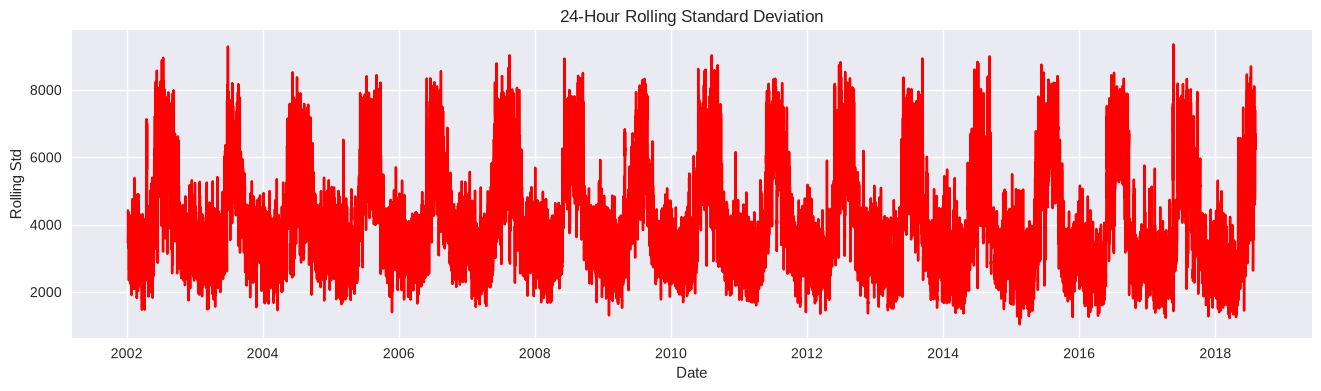

In [14]:
plt.figure(figsize=(16,4))
plt.plot(data['RollingStd_24'], color='red')
plt.title('24-Hour Rolling Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Rolling Std')
plt.show()

# Lag relationships

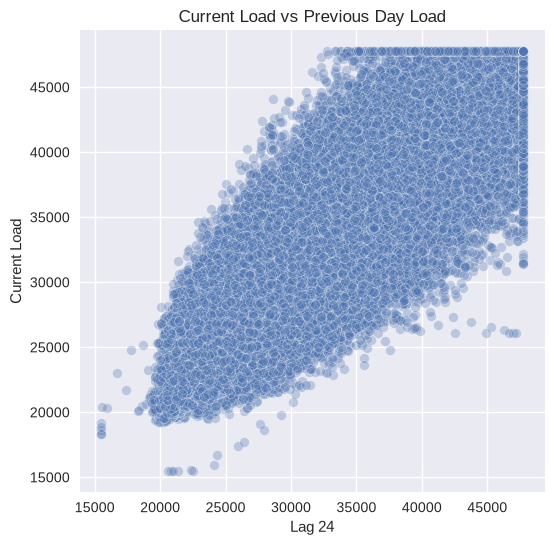

In [21]:
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=data['Lag_24'],
    y=data['PJME_MW'],
    alpha=0.3
)

plt.title('Current Load vs Previous Day Load')
plt.xlabel('Lag 24')
plt.ylabel('Current Load')
plt.show()

# Autocorrelation plot

<Figure size 1200x500 with 0 Axes>

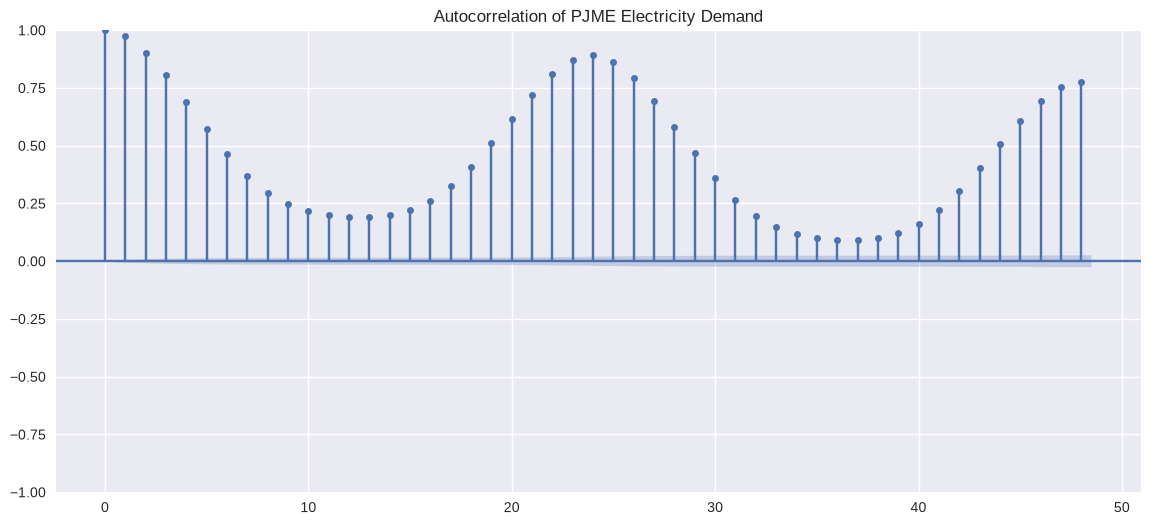

In [22]:
plt.figure(figsize=(12,5))
plot_acf(data['PJME_MW'], lags=48)
plt.title('Autocorrelation of PJME Electricity Demand')
plt.show()

# Seasonal decomposition

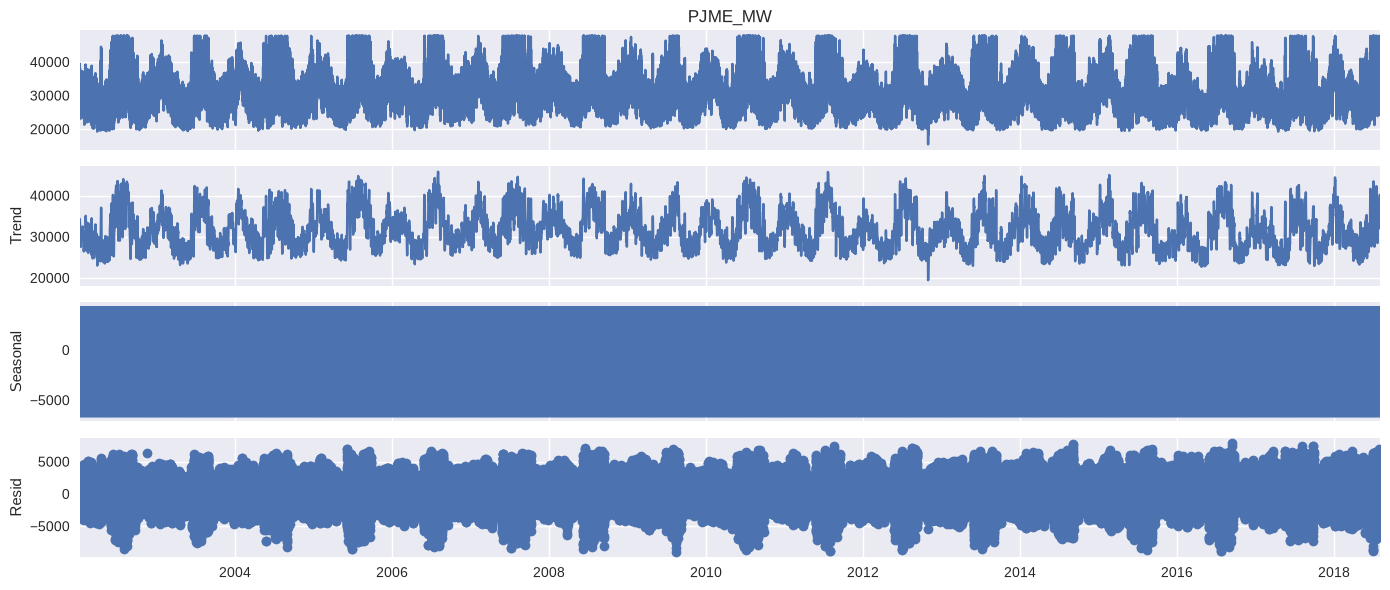

In [23]:
decomposition = seasonal_decompose(
    data['PJME_MW'],
    model='additive',
    period=24
)

decomposition.plot()
plt.show()